
# Задание №3. Скрытые характеристики ЭЭГ во время приступа

**Цель:** исследование скрытых характеристик сигналов электроэнцефалографии.

**Ключевые навыки:** расчёт спектральной плотности, вейвлет-преобразование.

**Что делаем по шагам:**

1. Скачиваем запись ЭЭГ из открытого датасета на Zenodo (`10.5281/zenodo.2547147`,
   неонатальные ЭЭГ с аннотациями приступов от 3-х экспертов).
2. По CSV-аннотации находим, где в записи помечен приступ.
3. Строим график ЭЭГ в момент приступа — все каналы.
4. Усредняем все каналы в один (сумма / число каналов).
5. Удаляем из сигнала всё выше 60 Гц (фильтр Баттерворта 8-го порядка, нулевая фаза).
6. Для отфильтрованного сигнала строим:
   1. **спектрограмму** (STFT — кратковременное преобразование Фурье);
   2. **скейлограмму** (CWT — непрерывное вейвлет-преобразование, базис Морле).

**Датасет.** 79 EDF-файлов от новорожденных в отделении интенсивной терапии
(NICU, Helsinki University Hospital). 19 каналов по схеме 10–20, частота
дискретизации 256 Гц, единицы — мкВ. Аннотации даны посекундно тремя экспертами
(`annotations_2017_A.csv`, `_B.csv`, `_C.csv`): 79 столбцов (по числу детей),
каждая строка = 1 секунда (1 — приступ, 0 — нет).



## 0. Установка зависимостей



In [2]:
#!pip install mne pyedflib pywavelets scipy matplotlib numpy pandas tqdm requests


## 1. Импорты

In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import scipy.signal as scisig
import pywt
import mne

mne.set_log_level("WARNING")        # без INFO-спама от MNE
plt.rc("figure", dpi=110)
plt.rc("axes", grid=True)

PLOT_WIDTH = 14   # ширина всех графиков (в дюймах) — крути под нужное значение


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 2. Скачивание данных с Zenodo

Берём:

* `eeg44.edf` — ребёнок №44, тяжёлая асфиксия. Из публикации в *Scientific Data*
  (Stevenson et al., 2019) известно, что около 5 мин 53 сек в этой записи
  заканчивается широкий приступный разряд. Файл небольшой (~36 МБ).
* `annotations_2017_A.csv` — посекундные метки эксперта A.



In [4]:
DATA_ROOT  = Path(".")
SUBJECT_ID = 44                                   # номер ребёнка (1..79). Можно поменять.
edf_path   = DATA_ROOT / f"eeg{SUBJECT_ID}.edf"
csv_path   = DATA_ROOT / "annotations_2017_A.csv"

ZENODO_BASE = "https://zenodo.org/records/2547147/files"
remote_map = {
    edf_path: f"{ZENODO_BASE}/eeg{SUBJECT_ID}.edf?download=1",
    csv_path: f"{ZENODO_BASE}/annotations_2017_A.csv?download=1",
}

def fetch_to_disk(target: Path, source_url: str) -> None:
    if target.exists() and target.stat().st_size > 0:
        print(f"уже есть: {target} ({target.stat().st_size/1e6:.1f} MB)")
        return
    print(f"скачиваю {source_url} -> {target}")
    with requests.get(source_url, stream=True, timeout=300) as resp:
        resp.raise_for_status()
        total = int(resp.headers.get("content-length", 0))
        with target.open("wb") as fout, tqdm(total=total, unit="B", unit_scale=True) as bar:
            for piece in resp.iter_content(chunk_size=1 << 15):
                if not piece:
                    continue
                fout.write(piece)
                bar.update(len(piece))

for dst, src in remote_map.items():
    fetch_to_disk(dst, src)


уже есть: eeg44.edf (36.1 MB)
уже есть: annotations_2017_A.csv (1.6 MB)



## 3. Где в записи приступ?

В CSV-аннотациях каждая колонка соответствует ребёнку (имена `1`, `2`, …, `79`),
каждая строка — секунда записи. `1` — секунда отнесена к приступу, `0` — нет,
`NaN` — у этого ребёнка запись закончилась раньше.

Найдём все интервалы приступов и возьмём первый из них для построения графиков.


In [5]:
ann_df = pd.read_csv(csv_path)
print("форма таблицы аннотаций:", ann_df.shape)        # (T_max_секунд, 79)
print("первые колонки:", list(ann_df.columns[:5]))

subject_col  = str(SUBJECT_ID)
seizure_mask = ann_df[subject_col].dropna().astype(int).to_numpy()   # 1/0 по секундам
n_secs       = len(seizure_mask)
print(f"\nдлительность аннотации для ребёнка #{SUBJECT_ID}: {n_secs} с "
      f"({n_secs/60:.1f} мин)")
print(f"всего секунд приступа: {seizure_mask.sum()}")

# подряд идущие 1-цы складываем в интервалы [start, end). Векторно через np.diff:
# по краям паддим нулями → +1 это «зашли» в приступ, -1 — «вышли».
def extract_intervals(mask: np.ndarray) -> list[tuple[int, int]]:
    flag  = np.asarray(mask, dtype=int)
    edges = np.diff(np.concatenate(([0], flag, [0])))
    rises = np.flatnonzero(edges ==  1)
    falls = np.flatnonzero(edges == -1)
    return [(int(a), int(b)) for a, b in zip(rises, falls)]

episodes = extract_intervals(seizure_mask)
print(f"\nнайдено {len(episodes)} приступов:")
for k, (a, b) in enumerate(episodes, start=1):
    print(f"  №{k}: {a} — {b} с  (длительность {b-a} с,  "
          f"{a//60} мин {a%60:02d} сек  →  {b//60} мин {b%60:02d} сек)")


форма таблицы аннотаций: (15416, 79)
первые колонки: ['1', '2', '3', '4', '5']

длительность аннотации для ребёнка #44: 3360 с (56.0 мин)
всего секунд приступа: 341

найдено 7 приступов:
  №1: 193 — 213 с  (длительность 20 с,  3 мин 13 сек  →  3 мин 33 сек)
  №2: 293 — 375 с  (длительность 82 с,  4 мин 53 сек  →  6 мин 15 сек)
  №3: 643 — 661 с  (длительность 18 с,  10 мин 43 сек  →  11 мин 01 сек)
  №4: 1058 — 1160 с  (длительность 102 с,  17 мин 38 сек  →  19 мин 20 сек)
  №5: 2503 — 2518 с  (длительность 15 с,  41 мин 43 сек  →  41 мин 58 сек)
  №6: 2969 — 2988 с  (длительность 19 с,  49 мин 29 сек  →  49 мин 48 сек)
  №7: 3023 — 3108 с  (длительность 85 с,  50 мин 23 сек  →  51 мин 48 сек)



## 4. Чтение EDF-файла




In [6]:
eeg = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")

duration_s = eeg.times[-1]
print(f"частота дискретизации: {eeg.info['sfreq']} Гц")
print(f"длительность: {duration_s} с ({duration_s/60} мин)")
print(f"число каналов: {len(eeg.ch_names)}")
print("каналы:", eeg.ch_names)


частота дискретизации: 256.0 Гц
длительность: 3359.99609375 с (55.999934895833334 мин)
число каналов: 21
каналы: ['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG Fz-REF', 'EEG Cz-REF', 'EEG Pz-REF', 'ECG EKG-REF', 'Resp Effort-REF']


In [7]:
import re

# электроды стандартной схемы 10-20
# (T3/T4/T5/T6 в части записей называются T7/T8/P7/P8 — учтены оба варианта)
EEG_1020 = frozenset({
    "Fp1", "Fp2",
    "F3", "F4", "F7", "F8", "Fz",
    "C3", "C4", "Cz",
    "P3", "P4", "Pz", "P7", "P8",
    "T3", "T4", "T5", "T6", "T7", "T8",
    "O1", "O2",
})

_NOISE_RE = re.compile(r"\bEEG\b|-Ref\b|-REF\b")
def standard_label(channel: str) -> str:
    """Достаём короткое имя электрода: 'EEG Fp1-Ref' -> 'Fp1'."""
    head = _NOISE_RE.sub("", channel).strip().split("-", 1)[0]
    return head.strip()

picked_chs = [ch for ch in eeg.ch_names if standard_label(ch) in EEG_1020]
print(f"оставлено ЭЭГ-каналов: {len(picked_chs)}")
print(picked_chs)

eeg.pick(picked_chs)
sample_rate = eeg.info["sfreq"]
print("итоговая частота дискретизации:", sample_rate, "Гц")


оставлено ЭЭГ-каналов: 19
['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG Fz-REF', 'EEG Cz-REF', 'EEG Pz-REF']
итоговая частота дискретизации: 256.0 Гц



## 5. Вырезаем фрагмент в момент приступа

`SEIZURE_INDEX` — порядковый номер приступа из найденных.


In [8]:
SEIZURE_INDEX = 2   # 0 = первый приступ, 3 = четвёртый и т.д.
PRE_SEC, POST_SEC = 60, 60   # сколько секунд показывать ДО / ПОСЛЕ приступа

if episodes:
    pick = min(SEIZURE_INDEX, len(episodes) - 1)
    if pick != SEIZURE_INDEX:
        print(f"запрошенного приступа №{SEIZURE_INDEX+1} нет, беру №{pick+1}")
    ep_start, ep_end = episodes[pick]
    print(f"используем приступ №{pick+1}: {ep_start} — {ep_end} с "
          f"(длительность {ep_end-ep_start} с)")
    win_start = max(0.0, ep_start - PRE_SEC)
    win_end   = min(eeg.times[-1], ep_end + POST_SEC)
else:
    print("приступов в этом файле не размечено — берём окно посередине записи")
    centre = eeg.times[-1] / 2
    win_start, win_end = centre - 30, centre + 30
    ep_start,  ep_end  = None,       None

print(f"вырезаем окно: {win_start:.1f} — {win_end:.1f} с "
      f"(длина {win_end-win_start:.1f} с)")

idx_lo = int(win_start * sample_rate)
idx_hi = int(win_end   * sample_rate)
traces = eeg.get_data(start=idx_lo, stop=idx_hi) * 1e6   # MNE отдаёт В → переводим в мкВ
time_axis = win_start + np.arange(traces.shape[1]) / sample_rate
print("форма traces:", traces.shape, " (n_channels, n_samples)")


используем приступ №3: 643 — 661 с (длительность 18 с)
вырезаем окно: 583.0 — 721.0 с (длина 138.0 с)
форма traces: (19, 35328)  (n_channels, n_samples)



## 6. График ЭЭГ в момент приступа — все каналы


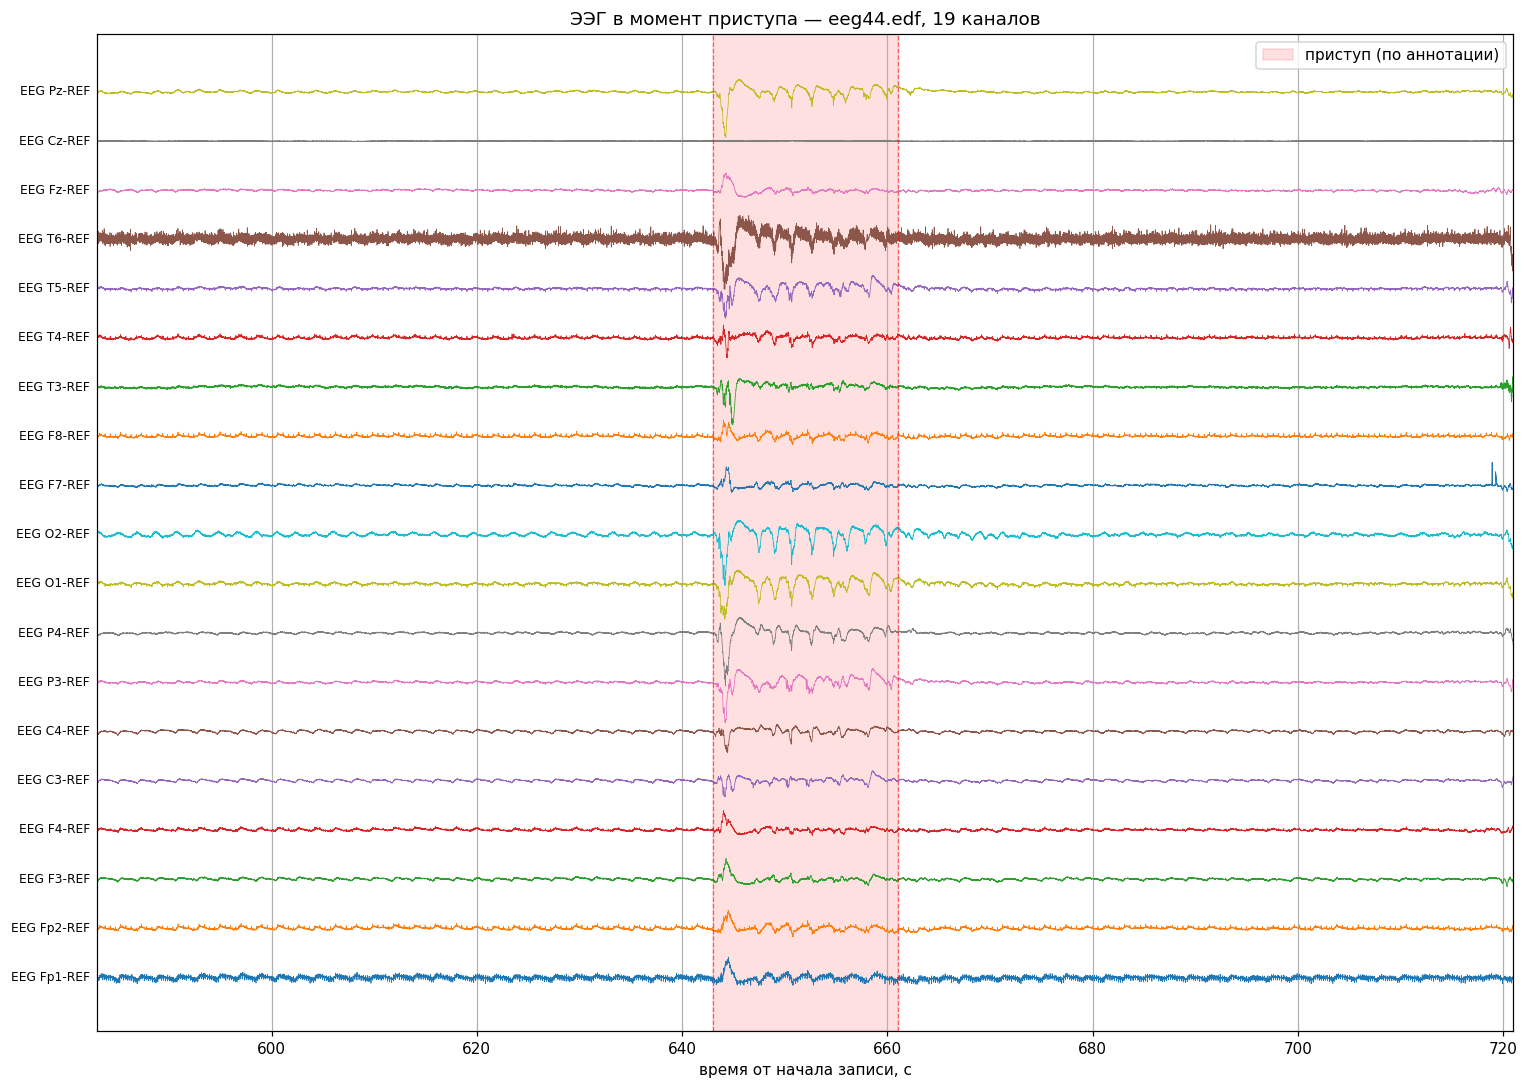

In [9]:
STACK_STEP = 150  # мкВ — расстояние между линиями каналов по вертикали

# вместо цикла со сложением: делаем broadcasting и одним вызовом рисуем все каналы
shifts  = np.arange(len(picked_chs)) * STACK_STEP
stacked = traces + shifts[:, None]

fig, ax = plt.subplots(figsize=(PLOT_WIDTH, 10))
ax.plot(time_axis, stacked.T, linewidth=0.5)

label_x = time_axis[0] - 0.005 * (time_axis[-1] - time_axis[0])
for y, name in zip(shifts, picked_chs):
    ax.text(label_x, y, name, va="center", ha="right", fontsize=8)

if ep_start is not None:
    ax.axvspan(ep_start, ep_end, color="red", alpha=0.12, label="приступ (по аннотации)")
    for x in (ep_start, ep_end):
        ax.axvline(x, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.legend(loc="upper right")

ax.set_yticks([])
ax.set_xlabel("время от начала записи, с")
ax.set_title(f"ЭЭГ в момент приступа — eeg{SUBJECT_ID}.edf, {len(picked_chs)} каналов")
ax.margins(x=0)
plt.tight_layout()
plt.show()



## 7. Усредняем каналы в один




форма усреднённого сигнала: (35328,)
размах: -40.9 … 17.7 мкВ


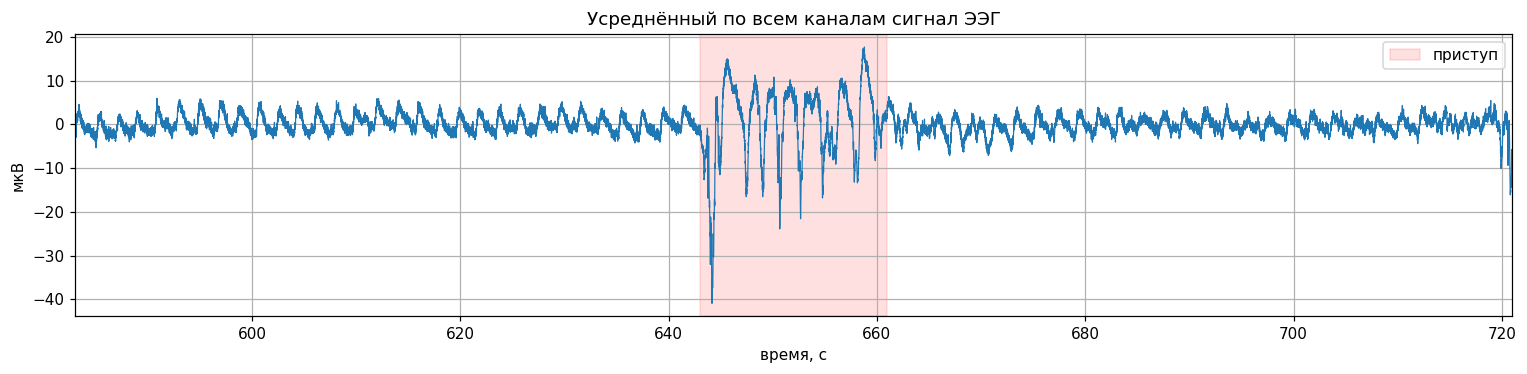

In [10]:
avg_trace = np.mean(traces, axis=0)   # эквивалент traces.sum(axis=0) / traces.shape[0]
print("форма усреднённого сигнала:", avg_trace.shape)
print(f"размах: {avg_trace.min():.1f} … {avg_trace.max():.1f} мкВ")

fig, ax = plt.subplots(figsize=(PLOT_WIDTH, 3.5))
ax.plot(time_axis, avg_trace, linewidth=0.8)
if ep_start is not None:
    ax.axvspan(ep_start, ep_end, color="red", alpha=0.12, label="приступ")
    ax.legend()
ax.set(xlabel="время, с", ylabel="мкВ",
       title="Усреднённый по всем каналам сигнал ЭЭГ")
ax.margins(x=0)
plt.tight_layout()
plt.show()



## 8. Удаляем частоты выше 60 Гц


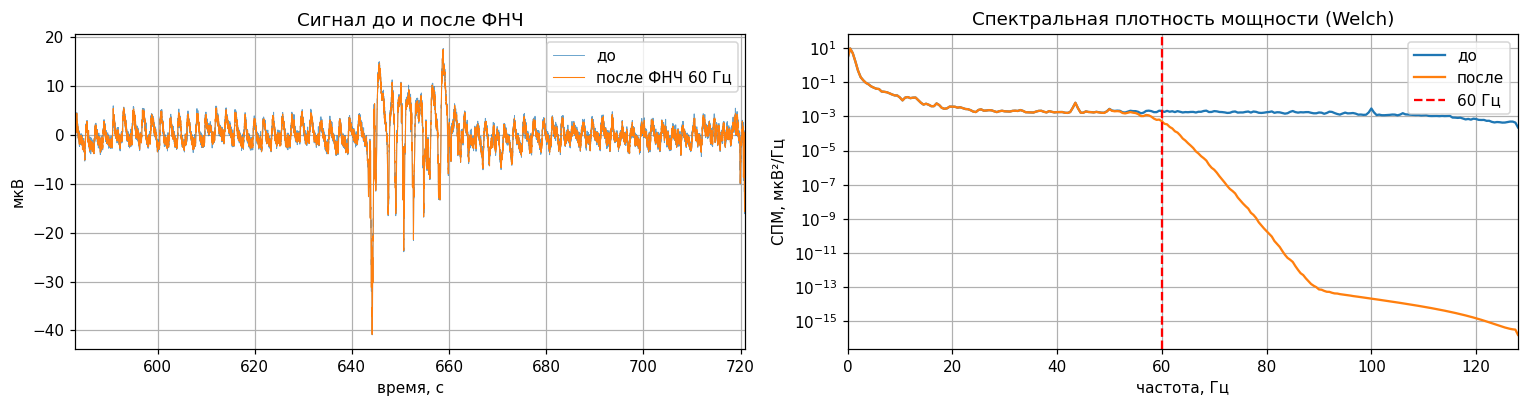

после фильтра энергия выше 60 Гц подавлена; ниже всё сохранено.


In [11]:
LP_HZ   = 60.0   # граница ФНЧ, Гц
biquads = scisig.butter(N=8, Wn=LP_HZ, btype="low", fs=sample_rate, output="sos")
trace_lp = scisig.sosfiltfilt(biquads, avg_trace)

# спектр до/после, чтобы убедиться, что ФНЧ работает корректно
def welch_psd(x, fs):
    return scisig.welch(x, fs=fs, nperseg=int(2 * fs))

freq_raw, psd_raw = welch_psd(avg_trace, sample_rate)
freq_lp,  psd_lp  = welch_psd(trace_lp,  sample_rate)

fig, (ax_t, ax_f) = plt.subplots(1, 2, figsize=(PLOT_WIDTH, 3.8))

ax_t.plot(time_axis, avg_trace, linewidth=0.6, alpha=0.7, label="до")
ax_t.plot(time_axis, trace_lp,  linewidth=0.7, label=f"после ФНЧ {LP_HZ:.0f} Гц")
ax_t.set(xlabel="время, с", ylabel="мкВ", title="Сигнал до и после ФНЧ")
ax_t.legend(); ax_t.margins(x=0)

ax_f.semilogy(freq_raw, psd_raw, label="до")
ax_f.semilogy(freq_lp,  psd_lp,  label="после")
ax_f.axvline(LP_HZ, color="red", linestyle="--", label=f"{LP_HZ:.0f} Гц")
ax_f.set_xlim(0, sample_rate / 2)
ax_f.set(xlabel="частота, Гц", ylabel="СПМ, мкВ²/Гц",
         title="Спектральная плотность мощности (Welch)")
ax_f.legend()

plt.tight_layout()
plt.show()

print("после фильтра энергия выше 60 Гц подавлена; ниже всё сохранено.")



## 9. Спектрограмма

Спектрограмма — это **кратковременное преобразование Фурье** (STFT): сигнал
режется на короткие пересекающиеся окна, в каждом считается ПФ, и квадрат
модуля рисуется как «частота × время → энергия».

Окно ≈ 1 с (`nperseg = fs`), перекрытие 75% — компромисс между разрешением
по времени и по частоте. Энергию показываем в децибелах относительно 1 мкВ²/Гц.


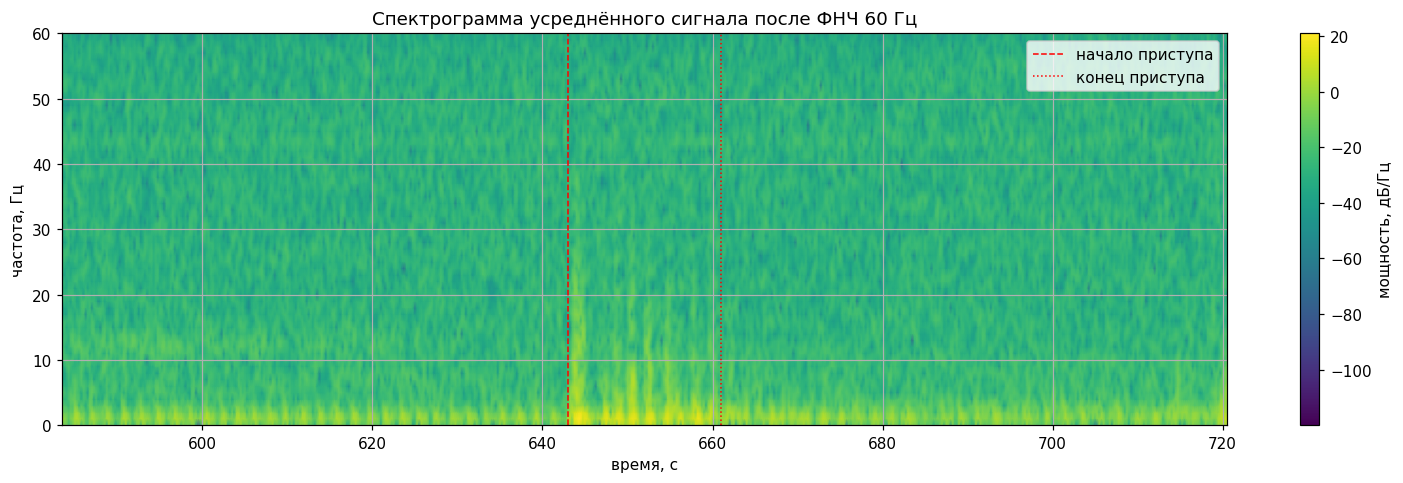

In [12]:
win_size = int(sample_rate)            # окно ≈ 1 секунда
overlap  = int(0.75 * win_size)        # перекрытие 75 %

stft_f, stft_t, stft_p = scisig.spectrogram(
    trace_lp, fs=sample_rate,
    nperseg=win_size, noverlap=overlap,
    window="hann", scaling="density",
)
# время спектрограммы — в координатах оригинальной записи
stft_t_abs = stft_t + win_start

fig, ax = plt.subplots(figsize=(PLOT_WIDTH, 4.5))
mesh = ax.pcolormesh(
    stft_t_abs, stft_f, 10 * np.log10(stft_p + 1e-12),
    shading="gouraud", cmap="viridis",
)
ax.set_ylim(0, LP_HZ)                  # частот выше LP_HZ всё равно нет
ax.set(xlabel="время, с", ylabel="частота, Гц",
       title=f"Спектрограмма усреднённого сигнала после ФНЧ {LP_HZ:.0f} Гц")

if ep_start is not None:
    ax.axvline(ep_start, color="red", linestyle="--", linewidth=1, label="начало приступа")
    ax.axvline(ep_end,   color="red", linestyle=":",  linewidth=1, label="конец приступа")
    ax.legend(loc="upper right")

plt.colorbar(mesh, ax=ax, label="мощность, дБ/Гц")
plt.tight_layout()
plt.show()



## 10. Скейлограмма — непрерывное вейвлет-преобразование

CWT даёт переменное частотно-временное разрешение: на низких частотах
лучше разрешение по частоте, на высоких — по времени, что хорошо подходит
к нестационарным ЭЭГ-разрядам.

Используем комплексный Морле


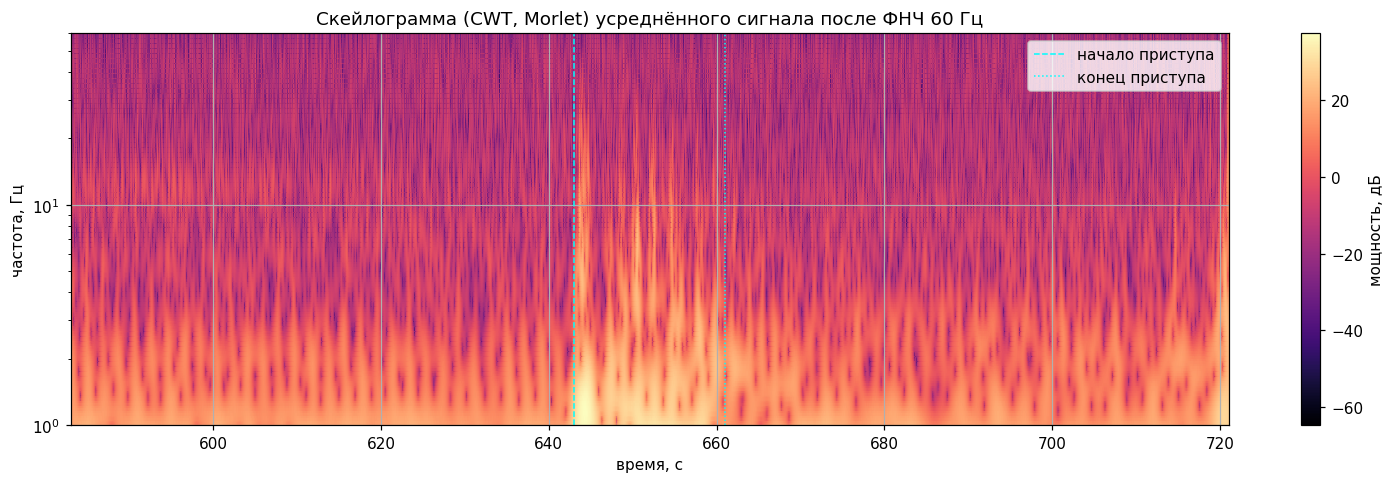

In [13]:
mother       = "cmor1.5-1.0"                      # bandwidth=1.5, center=1.0
target_freqs = np.geomspace(1.0, 60.0, num=80)    # эквивалент logspace(log10(1), log10(60), 80)
center_f     = pywt.central_frequency(mother)
cwt_scales   = center_f * sample_rate / target_freqs

cwt_c, cwt_f = pywt.cwt(trace_lp, cwt_scales, mother, sampling_period=1.0/sample_rate)
cwt_power    = np.abs(cwt_c) ** 2                 # энергия

fig, ax = plt.subplots(figsize=(PLOT_WIDTH, 4.5))
mesh = ax.pcolormesh(
    time_axis, cwt_f, 10 * np.log10(cwt_power + 1e-12),
    shading="gouraud", cmap="magma",
)
ax.set_yscale("log")
ax.set_ylim(1, LP_HZ)
ax.set(xlabel="время, с", ylabel="частота, Гц",
       title=f"Скейлограмма (CWT, Morlet) усреднённого сигнала после ФНЧ {LP_HZ:.0f} Гц")

if ep_start is not None:
    ax.axvline(ep_start, color="cyan", linestyle="--", linewidth=1, label="начало приступа")
    ax.axvline(ep_end,   color="cyan", linestyle=":",  linewidth=1, label="конец приступа")
    ax.legend(loc="upper right")

plt.colorbar(mesh, ax=ax, label="мощность, дБ")
plt.tight_layout()
plt.show()



## 11. Что мы видим

* **На временно́м графике** в момент приступа меняется характер сигнала —
  появляются ритмичные высоко-амплитудные колебания, которых в фоне не было.
  Это «скрытая» характеристика: глазом-то она видна, но количественно описать
  её во временной области трудно.

* **Спектрограмма** показывает, как энергия по частотам перераспределяется во
  времени: во время приступа в нижних частотах (обычно 1–8 Гц для неонатального
  приступа) появляется чёткая «горячая» полоса. Это и есть скрытая
  характеристика, которой нет в самой временной развёртке.

* **Скейлограмма** даёт ту же информацию, но с переменным разрешением:
  на низких частотах граница приступа размыта по времени (зато хорошо видна
  доминирующая частота), на верхних — наоборот. Поэтому для коротких
  ЭЭГ-разрядов CWT часто информативнее STFT.

* **ФНЧ 60 Гц** убирает мышечные артефакты и часть высокочастотного шума,
  сохраняя физиологически значимый диапазон ЭЭГ (дельта/тета/альфа/бета и
  низкие гамма-ритмы).

### Параметры, которые удобно крутить

* `EEG_ID` — другой ребёнок (1..79). По публикации Stevenson et al. (2019)
  явные приступы есть, например, в `eeg44.edf` (~5:53), `eeg50.edf` (37:39).
* `pre, post` — длина окна вокруг приступа.
* `nperseg, noverlap` — разрешение спектрограммы.
* `wavelet`, число частот в `freqs` — детальность скейлограммы.
